# Classification & non-i.i.d. data

[![Binder](https://mybinder.org/badge_logo.svg)](https://mybinder.org/v2/gh/Oulu-IMEDS/stambo/main?labpath=notebooks%2FClassification_non_iid.ipynb)

V1.0.0: © Aleksei Tiulpin, PhD, 2025

This notebook shows an end-to-end example on how one can compare two models on a test set where data has block-diagonal covariance (i.e. non-i.i.d. samples measured e.g. from the same patient)

## Imports

In [1]:
import stambo
import numpy as np

import matplotlib.pyplot as plt

from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedGroupKFold

SEED = 2025

stambo.__version__

'0.1.5'

## Generating synthetic data with block-diagonal covaraince

We use stambo's synthetic dataset generation functionality to generate the dataset in question.

In [25]:
np.random.seed(SEED)
n_subjects = 100
n_data = 300
data, y, subject_ids = stambo.synthetic.generate_non_iid_measurements(
    n_data=n_data,
    n_subjects=n_subjects,
    rho=0.5,             # Subject correlation between classes
    subj_sigma=1.0,
    noise_sigma=0.5,
    gamma=0.8,
    mu_cls_1=[2, 2],
    mu_cls_2=[2.4, 2.4],
    overlap=0.2,
    feat_corr=0.1,       # <--- High correlation between Dim 1 and Dim 2
    seed=42
)

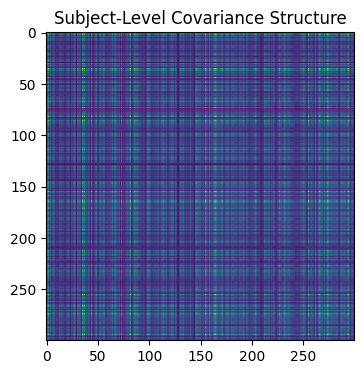

In [26]:
# Besides regenerating the data, we can also bootstrap the covariance matrix

plt.figure(figsize=(4, 4))
plt.imshow(data @ data.T)
plt.title("Subject-Level Covariance Structure")
plt.show()

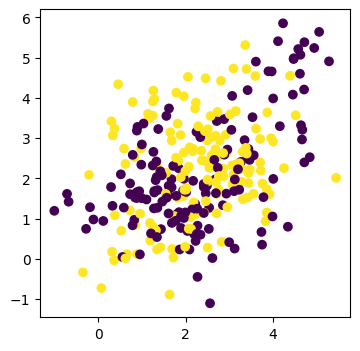

In [27]:
plt.figure(figsize=(4, 4))
plt.scatter(data[:, 0], data[:, 1], c=y)
plt.show()



In [28]:
gss = StratifiedGroupKFold(n_splits=3, shuffle=True, random_state=SEED)
train_idx, test_idx = next(gss.split(data, y, groups=subject_ids))

# Split the data into training and testing sets
X_train, X_test = data[train_idx], data[test_idx]
y_train, y_test = y[train_idx], y[test_idx]
groups_train, groups_test = subject_ids[train_idx], subject_ids[test_idx]

# Initialize classifiers
knn = KNeighborsClassifier(n_neighbors=5)
logreg = LogisticRegression()

# Train classifiers
knn.fit(X_train, y_train)
logreg.fit(X_train, y_train)

# Make predictions
knn_predictions = knn.predict(X_test)
logreg_predictions = logreg.predict(X_test)

In [29]:
testing_result = stambo.compare_models(y_test, knn_predictions, logreg_predictions, ("ROCAUC", "AP"),seed=SEED, n_bootstrap=1000)
print(stambo.to_latex(testing_result, m1_name="kNN", m2_name="LR"))

Bootstrapping: 100%|██████████| 1000/1000 [00:01<00:00, 818.27it/s]

% \usepackage{booktabs} <-- do not forget to have this imported. 
\begin{tabular}{lll} \\ 
\toprule 
\textbf{Model} & \textbf{ROCAUC} & \textbf{AP} \\ 
\midrule 
kNN & $0.63$ [$0.55$-$0.72$] & $0.59$ [$0.48$-$0.70$] \\ 
LR & $0.40$ [$0.31$-$0.49$] & $0.46$ [$0.38$-$0.56$] \\ 
\midrule
Effect size & $-0.23$ [$-0.35$-$-0.12]$ & $-0.12$ [$-0.21$-$-0.06]$ \\ 
\midrule
$p$-value & $0.00$ & $0.00$ \\ 
\bottomrule
\end{tabular}


In [31]:
testing_result = stambo.compare_models(y_test, knn_predictions, logreg_predictions, metrics=("ROCAUC", "AP"), groups=groups_test, seed=SEED, n_bootstrap=1000)
print(stambo.to_latex(testing_result, m1_name="kNN", m2_name="LR"))

Bootstrapping: 100%|██████████| 1000/1000 [00:01<00:00, 798.05it/s]

% \usepackage{booktabs} <-- do not forget to have this imported. 
\begin{tabular}{lll} \\ 
\toprule 
\textbf{Model} & \textbf{ROCAUC} & \textbf{AP} \\ 
\midrule 
kNN & $0.63$ [$0.50$-$0.79$] & $0.59$ [$0.41$-$0.77$] \\ 
LR & $0.40$ [$0.27$-$0.58$] & $0.46$ [$0.24$-$0.72$] \\ 
\midrule
Effect size & $-0.23$ [$-0.46$-$0.01]$ & $-0.12$ [$-0.29$-$0.01]$ \\ 
\midrule
$p$-value & $0.06$ & $0.06$ \\ 
\bottomrule
\end{tabular}


According to conventional bootstrap, we did not find any significant difference between the two models. Once we take into account the subject-level structure, we see that the difference is significant, which is valuable in applications.